<a href="https://colab.research.google.com/github/ZainabIftikhar1204/DL-for-Space-Time-and-Graphs---Assignment-1/blob/main/Task2_Autoformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports and Sources

In [2]:
from google.colab import drive
drive.mount("/content/drive")

DATA = "/content/drive/MyDrive/DL Temporal Assg 1"   # folder with the 3 CSVs; results are saved here too
import os; os.chdir(DATA); print(os.listdir(DATA))

Mounted at /content/drive
['optional_external_data.csv', 'student_train.csv', 'student_test.csv', 'autoformer_task2.py', '__pycache__', 'smoke.jsonl', 'abl.jsonl', 'preds.csv']


In [3]:
import argparse, copy, json, math, time
from types import SimpleNamespace
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as Fn

H = 168  # pred_len, fixed by the assignment
dev_name = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", dev_name)

torch 2.11.0+cu130 | device: cuda


## Data Exploration

In [4]:
TRAIN_DATA = f"{DATA}/student_train.csv"
SUPP_DATA = f"{DATA}/optional_external_data.csv"
train_df = pd.read_csv(TRAIN_DATA, index_col='time_idx')
# train_df = train_df[['value']]
supp_df = pd.read_csv(SUPP_DATA)

In [5]:
train_df.shape

(43656, 1)

In [6]:
supp_df.head()

,time_idx,feature_A,feature_B,feature_C,feature_D,feature_E,feature_F,feature_G,feature_H,feature_I,feature_J
0,1,-21,-11.0,1021.0,1.79,0,0,0,1,0,0
1,2,-21,-12.0,1020.0,4.92,0,0,0,1,0,0
2,3,-21,-11.0,1019.0,6.71,0,0,0,1,0,0
3,4,-21,-14.0,1019.0,9.84,0,0,0,1,0,0
4,5,-20,-12.0,1018.0,12.97,0,0,0,1,0,0


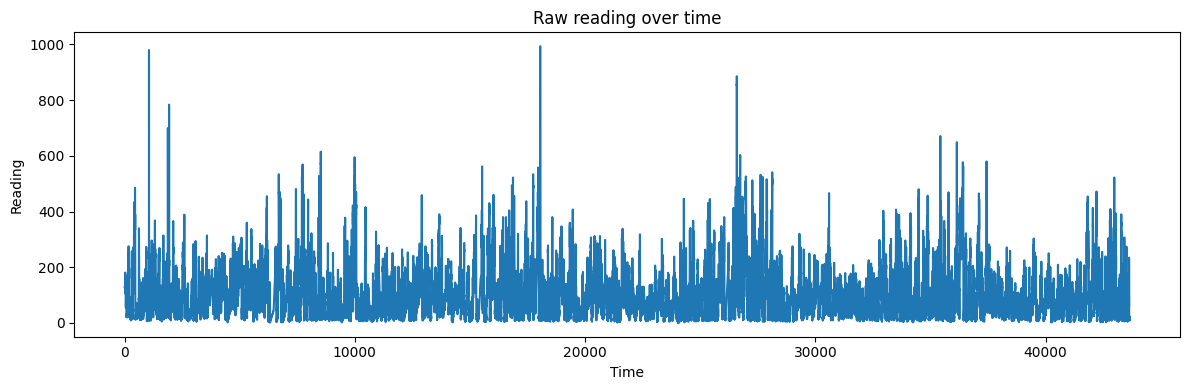

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(TRAIN_DATA)  # adjust column name

plt.figure(figsize=(12, 4))
plt.plot(df["time_idx"], df["value"])   # adjust column name
plt.xlabel("Time")
plt.ylabel("Reading")
plt.title("Raw reading over time")
plt.tight_layout()
plt.show()

In [9]:
supp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time_idx   43824 non-null  int64  
 1   feature_A  43824 non-null  int64  
 2   feature_B  43824 non-null  float64
 3   feature_C  43824 non-null  float64
 4   feature_D  43824 non-null  float64
 5   feature_E  43824 non-null  int64  
 6   feature_F  43824 non-null  int64  
 7   feature_G  43824 non-null  int64  
 8   feature_H  43824 non-null  int64  
 9   feature_I  43824 non-null  int64  
 10  feature_J  43824 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 3.7 MB


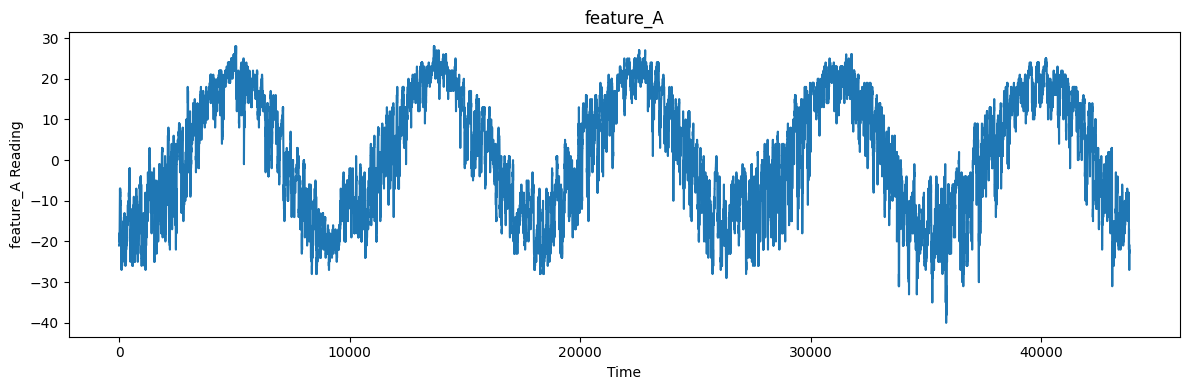

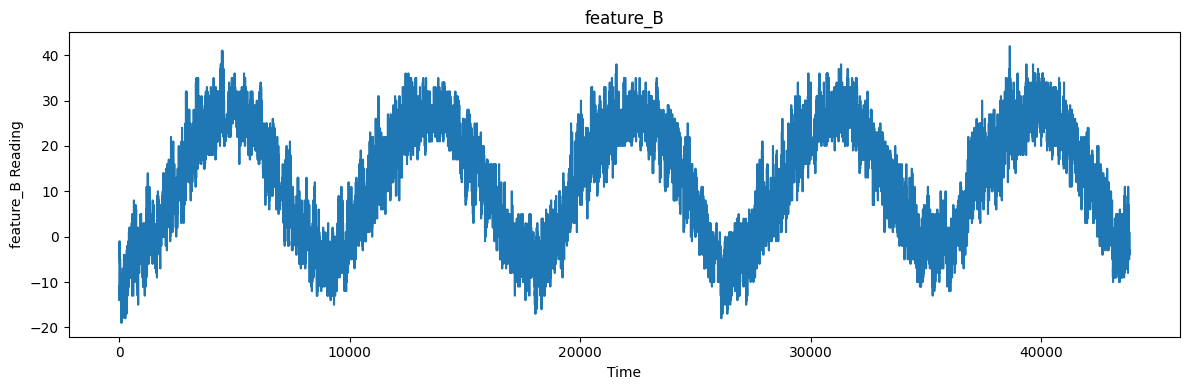

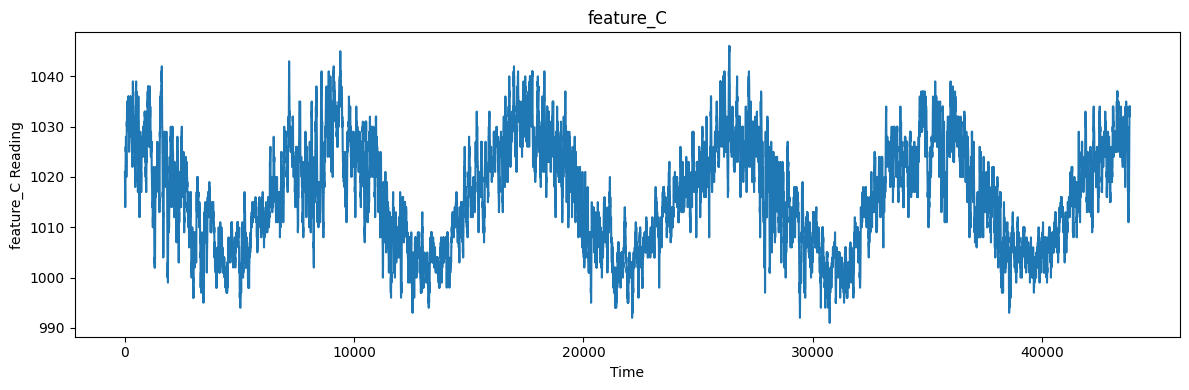

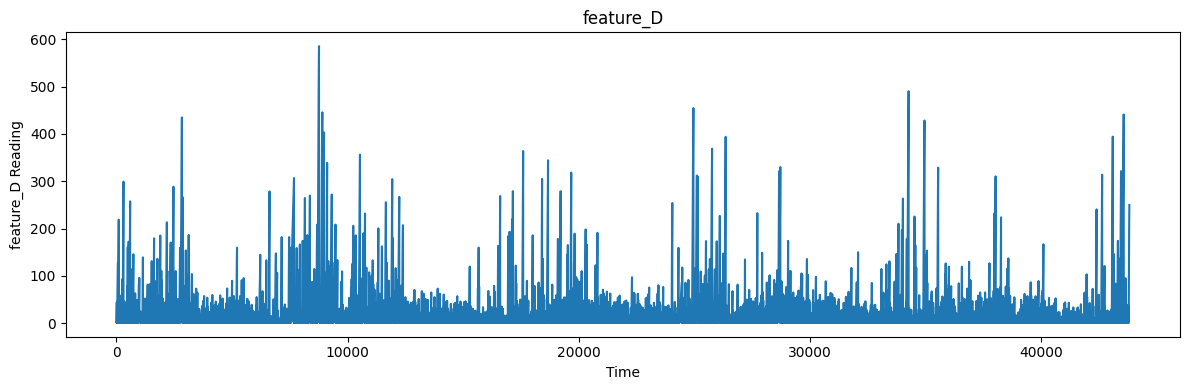

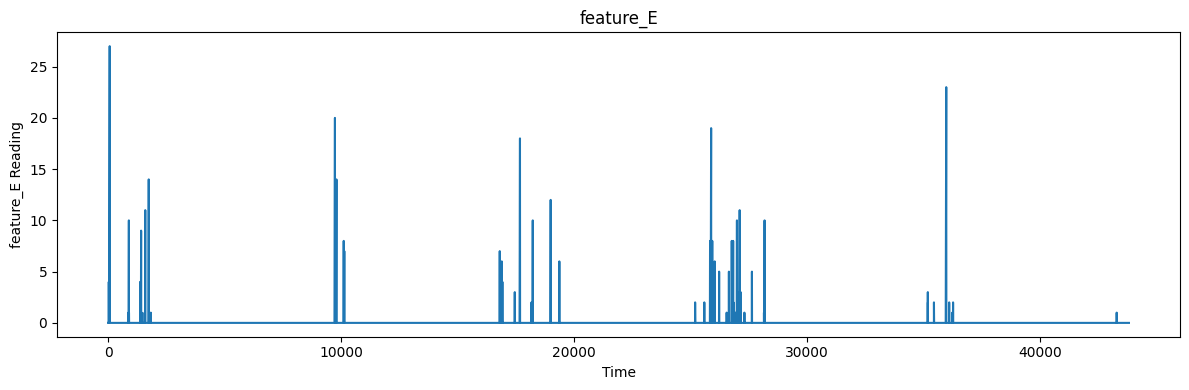

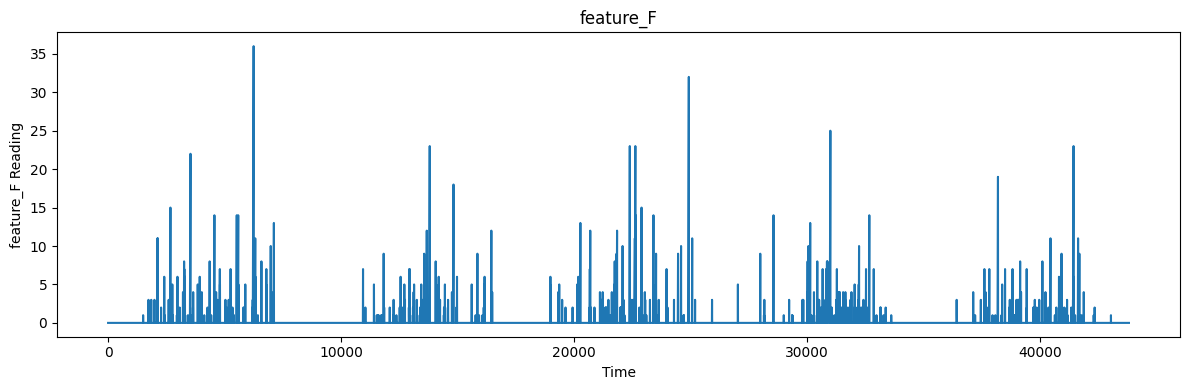

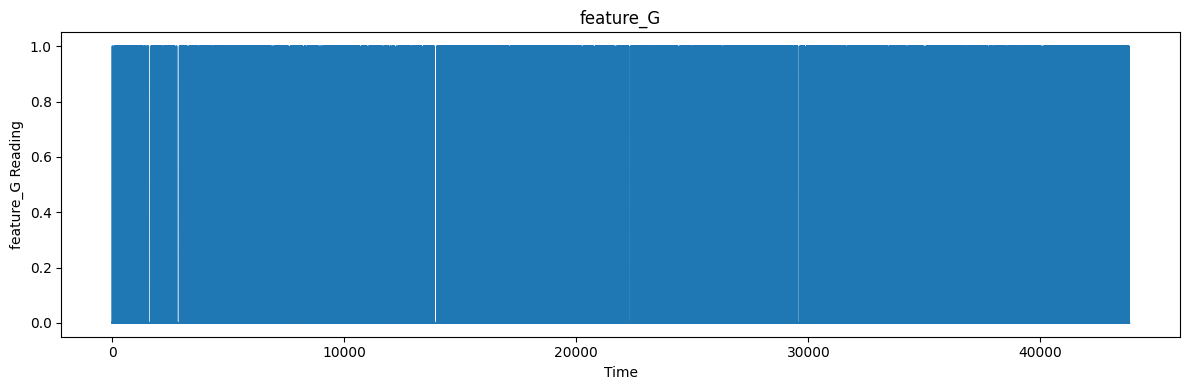

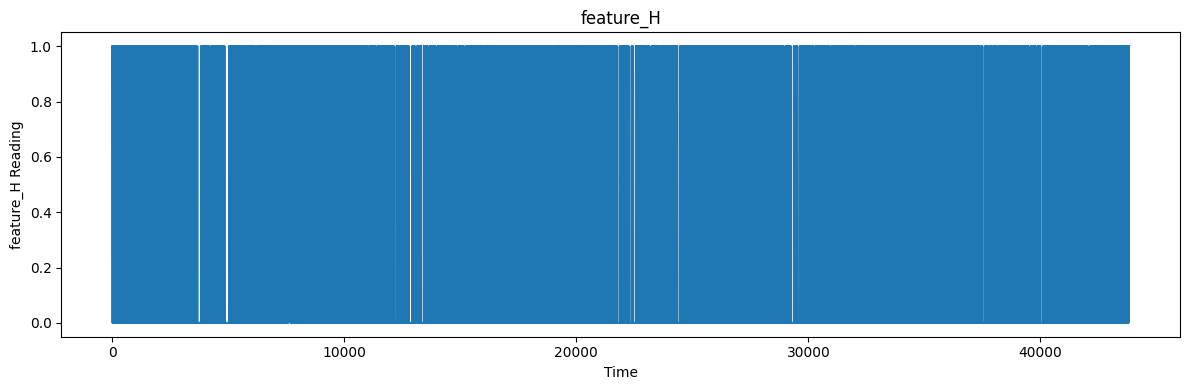

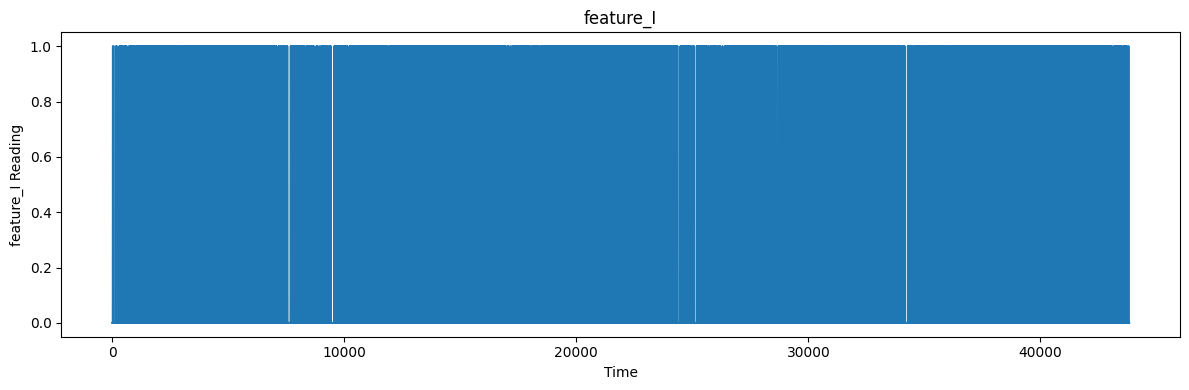

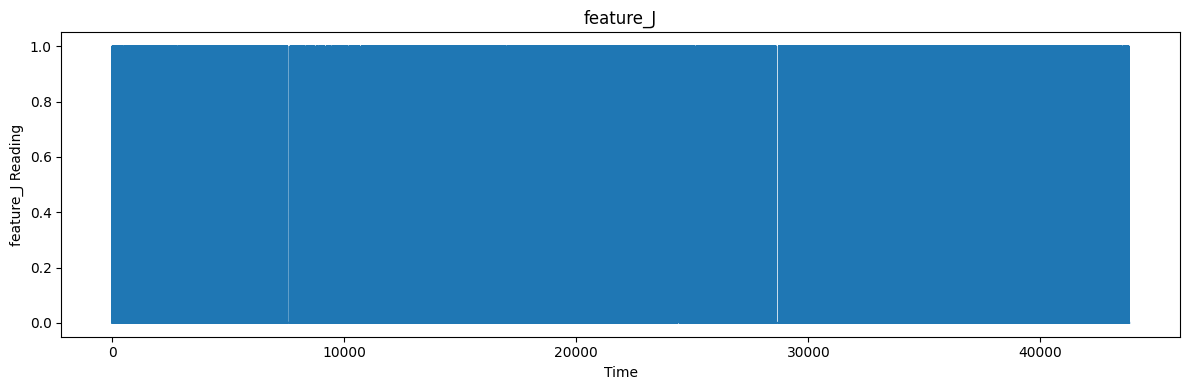

In [10]:
# for col in ["feature_A", "feature_B", "feature_C", "feature_D"]:
for col in ['feature_A', 'feature_B', 'feature_C', 'feature_D',
       'feature_E', 'feature_F', 'feature_G', 'feature_H', 'feature_I',
       'feature_J']:
  plt.figure(figsize=(12, 4))
  plt.plot(supp_df["time_idx"], supp_df[col])   # adjust column name
  plt.xlabel("Time")
  plt.ylabel(f"{col} Reading")
  plt.title(col)
  plt.tight_layout()
  plt.show()

### Periodogram

In [11]:

H = 168               # horizon
VAL_BLOCKS = 26
y = train_df["value"].values.astype(np.float64)
FIT_END = len(y) - VAL_BLOCKS * H                       # 39,288 -> last 26*168 steps are validation
VAL_STARTS = [FIT_END + b * H for b in range(VAL_BLOCKS)]
print("FIT_END", FIT_END, "| first/last validation block start", VAL_STARTS[0], VAL_STARTS[-1])

FIT_END 39288 | first/last validation block start 39288 43488


      period  energy_share
0  9822.0000        0.0226
1   269.0959        0.0101
2   377.7692        0.0097
3    24.0000        0.0085
4   392.8800        0.0083
5   530.9189        0.0082
6  3274.0000        0.0081
7  2806.2857        0.0079
8   982.2000        0.0074
9   138.8269        0.0062


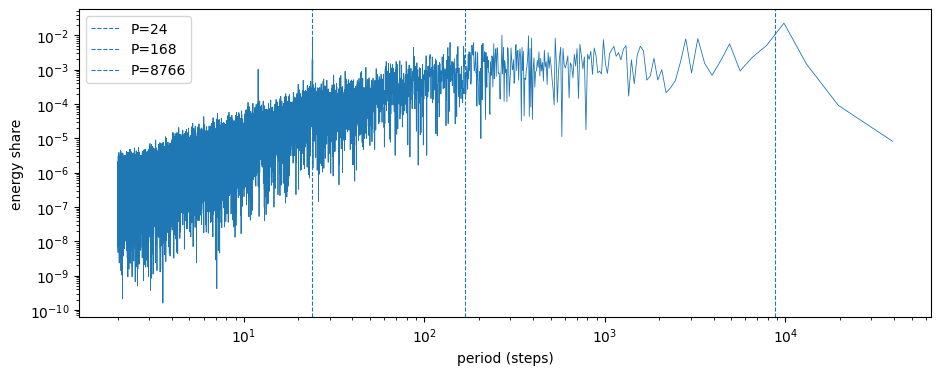

In [27]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import periodogram, find_peaks

y = pd.read_csv("student_train.csv")["value"].values.astype(float)
y = y[: len(y) - 26*168]                      # training rows before validation only

f, P = periodogram(y, fs=1.0, window="boxcar", detrend="constant", scaling="spectrum")
f, P = f[1:], P[1:]                           # drop the zero frequency
period = 1 / f
share = P / P.sum()

pk, _ = find_peaks(share)
top = pk[np.argsort(share[pk])[::-1][:10]]
print(pd.DataFrame({"period": period[top], "energy_share": share[top]}).round(4))

plt.figure(figsize=(11, 4))
plt.loglog(period, share, lw=.6)
for p_ in (24, 168, 8766): plt.axvline(p_, ls="--", lw=.8, label=f"P={p_}")
plt.xlabel("period (steps)"); plt.ylabel("energy share"); plt.legend(); plt.show()

### Decomposing into seasonal

In [28]:
import numpy as np, pandas as pd

y = pd.read_csv("student_train.csv")["value"].values.astype(float)
y = y[:len(y) - 26*168]                          # training rows before validation

def ma(x, m):                                    # centred moving average, edges padded
    q = (m - 1)//2; xp = np.r_[np.repeat(x[0], q), x, np.repeat(x[-1], q)]
    return np.convolve(xp, np.ones(m)/m, mode="valid")

def peak_table(x, k=6, same_cycle=0.03):
    n = len(x); x = x - x.mean()
    s = np.abs(np.fft.rfft(x))[1:] ** 2
    s = s / s.sum()                              # share of variance at each frequency
    loc = np.where((s[1:-1] > s[:-2]) & (s[1:-1] > s[2:]))[0] + 1
    rows = []
    for i in loc[np.argsort(s[loc])[::-1]]:
        per = n / (i + 1)
        if any(abs(per - r["period (steps)"]) / r["period (steps)"] < same_cycle for r in rows):
            continue                             # same cycle as one already listed
        rows.append({"rank": len(rows) + 1, "period (steps)": round(per, 1),
                     "cycles in data": i + 1, "% of variance": round(100 * s[i], 2)})
        if len(rows) == k: break
    return pd.DataFrame(rows)

print("RAW SERIES");  print(peak_table(y).to_string(index=False))
for m in [25, 49]:
    print(f"\nAFTER REMOVING SLOW TREND (y minus moving average of {m})")
    print(peak_table(y - ma(y, m)).to_string(index=False))

RAW SERIES
 rank  period (steps)  cycles in data  % of variance
    1          9822.0               4           2.26
    2           269.1             146           1.01
    3           377.8             104           0.97
    4            24.0            1637           0.85
    5           392.9             100           0.83
    6           530.9              74           0.82

AFTER REMOVING SLOW TREND (y minus moving average of 25)
 rank  period (steps)  cycles in data  % of variance
    1            24.0            1637           4.52
    2            12.0            3274           0.46
    3            21.3            1842           0.31
    4            20.0            1964           0.26
    5            22.5            1748           0.21
    6            27.7            1418           0.21

AFTER REMOVING SLOW TREND (y minus moving average of 49)
 rank  period (steps)  cycles in data  % of variance
    1            24.0            1637           2.49
    2            36.4    

After decomposing trend and keeping seasonal part of signal, 24 has most cycles in data and also a high variance. so 24 is a good choice for period.

In [33]:
## doing same for trend cyclical part
for m in [25, 169, 721]:
  T = ma(y, m)
  print(f"\nTREND PART: moving average of {m}  (holds {100*T.var()/y.var():.0f}% of the series' variance)")
  print(peak_table(T).to_string(index=False))


TREND PART: moving average of 25  (holds 71% of the series' variance)
 rank  period (steps)  cycles in data  % of variance
    1          9822.0               4           3.21
    2           269.1             146           1.40
    3           377.8             104           1.36
    4           530.9              74           1.16
    5           392.9             100           1.15
    6          3274.0              12           1.15

TREND PART: moving average of 169  (holds 24% of the series' variance)
 rank  period (steps)  cycles in data  % of variance
    1          9822.0               4           9.19
    2          3274.0              12           3.29
    3          2806.3              14           3.18
    4           982.2              40           2.80
    5           530.9              74           2.38
    6          4911.0               8           2.26

TREND PART: moving average of 721  (holds 8% of the series' variance)
 rank  period (steps)  cycles in data  % of 

## Model (progressive decomposition + FFT auto-correlation)

In [15]:
# ----------------------------------------------------------------- model ----
class MovingAvg(nn.Module):
    def __init__(s, k):
        super().__init__()
        assert k % 2 == 1, "moving_avg kernel must be odd"
        s.k = k
        s.avg = nn.AvgPool1d(k, 1, 0)

    def forward(s, x):  # [B, L, C]; replicate-pad both ends
        p = (s.k - 1) // 2
        x = torch.cat([x[:, :1].repeat(1, p, 1), x, x[:, -1:].repeat(1, p, 1)], 1)
        return s.avg(x.transpose(1, 2)).transpose(1, 2)


class Decomp(nn.Module):
    def __init__(s, k):
        super().__init__()
        s.ma = MovingAvg(k)

    def forward(s, x):  # -> seasonal, trend
        t = s.ma(x)
        return x - t, t


class AutoCorr(nn.Module):
    """FFT auto-correlation; per-example top-k delays; softmax-weighted roll-sum."""

    def __init__(s, factor):
        super().__init__()
        s.factor = factor

    def forward(s, q, k, v):  # [B, L, h, E]
        B, L, h, E = q.shape
        S = v.shape[1]
        if L > S:
            z = torch.zeros_like(q[:, : L - S])
            v = torch.cat([v, z], 1)
            k = torch.cat([k, z], 1)
        else:
            v, k = v[:, :L], k[:, :L]
        qf = torch.fft.rfft(q.permute(0, 2, 3, 1).contiguous(), dim=-1)
        kf = torch.fft.rfft(k.permute(0, 2, 3, 1).contiguous(), dim=-1)
        corr = torch.fft.irfft(qf * torch.conj(kf), n=L, dim=-1)  # [B,h,E,L]
        score = corr.mean(dim=(1, 2))  # [B, L] one score per delay
        top = max(1, int(s.factor * math.log(L)))
        w, d = torch.topk(score, top, dim=-1)  # [B, top]
        w = torch.softmax(w, -1)
        idx = (torch.arange(L, device=q.device)[None, None, :] + d[:, :, None]) % L
        vv = v.permute(0, 2, 3, 1)  # [B,h,E,L]
        g = vv.unsqueeze(1).expand(B, top, h, E, L)
        g = g.gather(-1, idx[:, :, None, None, :].expand(B, top, h, E, L))
        out = (g * w[:, :, None, None, None]).sum(1)  # out[t] = sum_j w_j v[t+d_j]
        return out.permute(0, 3, 1, 2)  # [B, L, h, E]


class ACLayer(nn.Module):
    def __init__(s, d, heads, factor):
        super().__init__()
        assert d % heads == 0
        s.h = heads
        s.q, s.k, s.v, s.o = (nn.Linear(d, d) for _ in range(4))
        s.ac = AutoCorr(factor)

    def forward(s, q, k, v):
        B, L, _ = q.shape
        S = k.shape[1]
        Q = s.q(q).view(B, L, s.h, -1)
        K = s.k(k).view(B, S, s.h, -1)
        V = s.v(v).view(B, S, s.h, -1)
        return s.o(s.ac(Q, K, V).reshape(B, L, -1))


class FFN(nn.Module):
    def __init__(s, d, dff, drop):
        super().__init__()
        s.c1 = nn.Conv1d(d, dff, 1, bias=False)
        s.c2 = nn.Conv1d(dff, d, 1, bias=False)
        s.drop = nn.Dropout(drop)

    def forward(s, x):
        y = s.drop(Fn.gelu(s.c1(x.transpose(1, 2))))
        return s.drop(s.c2(y).transpose(1, 2))


class EncLayer(nn.Module):
    def __init__(s, a):
        super().__init__()
        s.attn = ACLayer(a.d_model, a.heads, a.factor)
        s.ffn = FFN(a.d_model, a.d_ff, a.dropout)
        s.d1, s.d2 = Decomp(a.ma), Decomp(a.ma)
        s.drop = nn.Dropout(a.dropout)

    def forward(s, x):
        x, _ = s.d1(x + s.drop(s.attn(x, x, x)))
        x, _ = s.d2(x + s.ffn(x))
        return x


class DecLayer(nn.Module):
    def __init__(s, a):
        super().__init__()
        s.sa = ACLayer(a.d_model, a.heads, a.factor)
        s.ca = ACLayer(a.d_model, a.heads, a.factor)
        s.ffn = FFN(a.d_model, a.d_ff, a.dropout)
        s.d1, s.d2, s.d3 = Decomp(a.ma), Decomp(a.ma), Decomp(a.ma)
        s.proj = nn.Conv1d(a.d_model, 1, 3, padding=1, padding_mode="circular", bias=False)
        s.drop = nn.Dropout(a.dropout)

    def forward(s, x, cross):
        x, t1 = s.d1(x + s.drop(s.sa(x, x, x)))
        x, t2 = s.d2(x + s.drop(s.ca(x, cross, cross)))
        x, t3 = s.d3(x + s.ffn(x))
        tr = s.proj((t1 + t2 + t3).transpose(1, 2)).transpose(1, 2)  # [B, L, 1]
        return x, tr


class SeasonalLN(nn.Module):  # LayerNorm, then remove the per-sequence mean
    def __init__(s, d):
        super().__init__()
        s.ln = nn.LayerNorm(d)

    def forward(s, x):
        xh = s.ln(x)
        return xh - xh.mean(1, keepdim=True)


class Autoformer(nn.Module):
    def __init__(s, a, ncov):
        super().__init__()
        s.a = a
        cin = 1 + ncov
        d = a.d_model
        s.emb_e = nn.Conv1d(cin, d, 3, padding=1, padding_mode="circular", bias=False)
        s.emb_d = nn.Conv1d(cin, d, 3, padding=1, padding_mode="circular", bias=False)
        s.drop = nn.Dropout(a.dropout)
        s.dec_ma = Decomp(a.ma)
        s.enc = nn.ModuleList([EncLayer(a) for _ in range(a.e_layers)])
        s.dec = nn.ModuleList([DecLayer(a) for _ in range(a.d_layers)])
        s.norm_e, s.norm_d = SeasonalLN(d), SeasonalLN(d)
        s.out = nn.Linear(d, 1)

    def forward(s, xe, cd):
        """xe [B, seq, 1+ncov] (channel 0 = scaled target); cd [B, label+H, ncov]."""
        a = s.a
        B = xe.shape[0]
        if a.norm == "window":  # reversible per-window normalisation of the target
            m = xe[:, :, :1].mean(1, keepdim=True)
            sd = xe[:, :, :1].std(1, keepdim=True) + 1e-5
            xe = torch.cat([(xe[:, :, :1] - m) / sd, xe[:, :, 1:]], -1)
        y = xe[:, :, :1]
        seas, trend = s.dec_ma(y)
        mean = y.mean(1, keepdim=True).repeat(1, H, 1)
        trend_init = torch.cat([trend[:, -a.label:], mean], 1)
        seas_init = torch.cat([seas[:, -a.label:], torch.zeros(B, H, 1, device=xe.device)], 1)
        xd = torch.cat([seas_init, cd], -1)

        e = s.drop(s.emb_e(xe.transpose(1, 2)).transpose(1, 2))
        for l in s.enc:
            e = l(e)
        e = s.norm_e(e)
        x = s.drop(s.emb_d(xd.transpose(1, 2)).transpose(1, 2))
        tr = trend_init
        for l in s.dec:
            x, rt = l(x, e)
            tr = tr + rt
        out = (s.out(s.norm_d(x)) + tr)[:, -H:, 0]
        if a.norm == "window":
            out = out * sd[:, :, 0] + m[:, :, 0]
        return out


### Data, features, metrics

In [16]:
# ------------------------------------------------------------------ data ----
def build_data(a, fit_end):
    tr = pd.read_csv(f"{a.data}/student_train.csv")
    ex = pd.read_csv(f"{a.data}/optional_external_data.csv")
    y = tr["value"].values.astype(np.float64)
    n = len(y)
    tidx = ex["time_idx"].values.astype(np.float64)
    parts = []
    if a.cov in ("all", "cont"):
        cols = ["feature_A", "feature_B", "feature_C", "feature_D"]
        if a.use_ef:
            cols += ["feature_E", "feature_F"]
        c = ex[cols].values.astype(np.float64)
        c[:, 3] = np.log1p(c[:, 3])  # wind-like cumulative feature is skewed
        mu, sd = c[:fit_end].mean(0), c[:fit_end].std(0) + 1e-6
        parts.append((c - mu) / sd)
    if a.cov in ("all", "cat"):
        parts.append(ex[["feature_G", "feature_H", "feature_I", "feature_J"]].values.astype(np.float64))
    for P in a.periods:  # periods from the FFT
        ang = 2 * np.pi * tidx / P
        parts.append(np.stack([np.sin(ang), np.cos(ang)], 1))
    cov = np.concatenate(parts, 1).astype(np.float32) if parts else np.zeros((len(ex), 0), np.float32)
    yt = np.log1p(y) if a.log else y
    mu_y, sd_y = yt[:fit_end].mean(), yt[:fit_end].std()
    return y, ((yt - mu_y) / sd_y).astype(np.float32), cov, mu_y, sd_y, n


def to_raw(z, mu, sd, a):
    v = z * sd + mu
    if a.log:
        v = np.expm1(v)
    return np.clip(v, 0, None)


def batch(a, ys, cov, origins, dev, with_y=True):
    o = np.asarray(origins)
    ie = o[:, None] + np.arange(-a.seq, 0)[None]
    xe = np.concatenate([ys[ie][..., None], cov[ie]], -1)
    idd = o[:, None] + np.arange(-a.label, H)[None]
    cd = cov[idd].copy()
    if not a.cov_future:
        cd[:, a.label:] = 0
    t = lambda z: torch.from_numpy(np.ascontiguousarray(z)).float().to(dev)
    out = [t(xe), t(cd)]
    if with_y:
        out.append(t(ys[o[:, None] + np.arange(H)[None]]))
    return out


@torch.no_grad()
def predict(model, a, ys, cov, origins, dev, mu, sd):
    model.eval()
    P = []
    for i in range(0, len(origins), 64):
        xe, cd = batch(a, ys, cov, origins[i:i + 64], dev, with_y=False)
        P.append(model(xe, cd).cpu().numpy())
    return to_raw(np.concatenate(P), mu, sd, a)


def metrics(t, p):
    e = t - p
    den = np.abs(t) + np.abs(p)
    sm = np.where(den == 0, 0.0, 2 * np.abs(e) / np.where(den == 0, 1, den)) * 100
    return float(np.sqrt((e ** 2).mean())), float(np.abs(e).mean()), float(sm.mean())


### Training loop

In [17]:
# -------------------------------------------------------------- training ----
def train_one(a, seed, y, ys, cov, mu, sd, fit_end, val_starts, dev, fixed_epochs=None):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    model = Autoformer(a, cov.shape[1]).to(dev)
    P = sum(p.numel() for p in model.parameters() if p.requires_grad)
    opt = torch.optim.Adam(model.parameters(), lr=a.lr)
    n_es = a.es_blocks
    best, best_state, best_ep, bad, ep_run = 1e18, None, 0, 0, 0
    max_ep = fixed_epochs or a.epochs
    t0 = time.time()
    for ep in range(1, max_ep + 1):
        model.train()
        for g in opt.param_groups:
            g["lr"] = a.lr * (a.lr_decay ** (ep - 1))
        origins = np.arange(a.seq + rng.integers(a.stride), fit_end - H + 1, a.stride)
        rng.shuffle(origins)
        for i in range(0, len(origins), a.bs):
            xe, cd, yy = batch(a, ys, cov, origins[i:i + a.bs], dev)
            loss = Fn.mse_loss(model(xe, cd), yy)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        ep_run = ep
        if fixed_epochs is None:
            pr = predict(model, a, ys, cov, val_starts[:n_es], dev, mu, sd)
            r = np.mean([metrics(y[s:s + H], pr[j])[0] for j, s in enumerate(val_starts[:n_es])])
            print(f"  seed {seed} ep {ep} train_loss {loss.item():.4f} es_rmse {r:.2f}", flush=True)
            if r < best - 1e-6:
                best, best_state, best_ep, bad = r, copy.deepcopy(model.state_dict()), ep, 0
            else:
                bad += 1
                if bad >= a.patience:
                    break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, P, ep_run, best_ep, time.time() - t0


### Run harness (validation mode and final mode)

In [34]:
def execute(a):
    dev = "cuda" if torch.cuda.is_available() else "cpu"

    if a.final:
        y, ys, cov, mu, sd, n = build_data(a, fit_end=len(pd.read_csv(f"{a.data}/student_train.csv")))
        preds, Ptot, Etot = [], 0, 0
        for sd_ in a.seeds:
            m, P, ep, _, _ = train_one(a, sd_, y, ys, cov, mu, sd, n, [], dev, fixed_epochs=a.final_epochs)
            preds.append(predict(m, a, ys, cov, [n], dev, mu, sd)[0])
            Ptot += P
            Etot += ep
        p = np.mean(preds, 0)
        pd.DataFrame({"time_idx": np.arange(n + 1, n + H + 1), "value": p}).to_csv("preds.csv", index=False)
        print("PASTE:", ",".join(f"{v:.4f}" for v in p))
        print(f"declare P={Ptot} (sum over {len(a.seeds)} models), E={Etot}; add early-stopping epochs if you ran validation first")
        return dict(preds=p, params=Ptot, epochs=Etot)

    n_total = len(pd.read_csv(f"{a.data}/student_train.csv"))
    val_end = a.val_end or n_total
    fit_end = val_end - a.val_blocks * H
    val_starts = [fit_end + b * H for b in range(a.val_blocks)]
    y, ys, cov, mu, sd, n = build_data(a, fit_end)
    recs = []
    for seed in a.seeds:
        model, P, ep_run, best_ep, secs = train_one(a, seed, y, ys, cov, mu, sd, fit_end, val_starts, dev)
        pr = predict(model, a, ys, cov, val_starts, dev, mu, sd)
        M = np.array([metrics(y[s:s + H], pr[j]) for j, s in enumerate(val_starts)])  # [blocks, 3]
        rec = dict(name=a.name, seed=seed, params=P, epochs_run=ep_run, best_epoch=best_ep, secs=round(secs, 1),
                   cfg={k: v for k, v in vars(a).items() if k not in ("out",)},
                   rmse_all=M[:, 0].mean(), mae_all=M[:, 1].mean(), smape_all=M[:, 2].mean(),
                   rmse_confirm=M[a.es_blocks:, 0].mean() if a.val_blocks > a.es_blocks else None,
                   rmse_blocks=M[:, 0].round(2).tolist())
        # print(f"{a.name} seed {seed}: P={P} ep={ep_run}/{best_ep} RMSE all {rec['rmse_all']:.2f} "
        #       f"confirm {rec['rmse_confirm']} MAE {rec['mae_all']:.2f} sMAPE {rec['smape_all']:.1f}", flush=True)
        conf = rec["rmse_confirm"]; conf_s = f"{conf:.2f}" if conf is not None else "n/a"
        print(f"[{a.name} | seed {seed}]  params {P:,} | epochs run {ep_run} (best {best_ep}) | "
              f"RMSE {rec['rmse_all']:.2f}  confirm {conf_s} | MAE {rec['mae_all']:.2f} | sMAPE {rec['smape_all']:.1f}%",
              flush=True)
        recs.append(rec)
        with open(a.out, "a") as f:
            f.write(json.dumps(rec) + "\n")
    return pd.DataFrame(recs)


In [35]:
# Default hyper-parameters
DEFAULTS = dict(
    data=DATA, out="results.jsonl", name="run", seeds=[0, 1, 2, 3, 4],
    # covariates / features
    cov="all",          # none | cont | cat | all
    cov_future=1,       # 1: horizon covariates fed to decoder; 0: past-only
    use_ef=0,           # include feature_E/F (all 0 over the horizon)
    periods=[],         # sin/cos periods from time_idx
    # target handling
    log=0, norm="global",   # norm: global | window
    # model
    seq=120, label=96, d_model=32, heads=4, d_ff=64, e_layers=1, d_layers=1,
    ma=25, factor=1.0, dropout=0.1,
    # optimisation
    epochs=15, patience=3, lr=1e-3, lr_decay=0.8, bs=64, stride=6,
    # validation
    val_blocks=26, es_blocks=13, val_end=0,
    # final fit
    final=False, final_epochs=8,
)

def run(**kw):
    """df = run(name="nocov", cov="none", seeds=[0,1,2], epochs=15)
    Validation mode -> DataFrame (one row per seed). final=True -> dict(preds, params, epochs) + preds.csv."""
    bad = set(kw) - set(DEFAULTS)
    if bad: raise ValueError(f"unknown option(s) {sorted(bad)}; valid: {sorted(DEFAULTS)}")
    a = SimpleNamespace(**{**DEFAULTS, **kw})
    return execute(a)

## Evaluations & Ablations

### Checking Diff Periods

In [38]:
S = [0, 1, 2, 3, 4]
tests = {
    "tf_24":        dict(periods=[24]), #daily
    "tf_12":        dict(periods=[12]), #half day
}
for name, kw in tests.items():
    run(name=name, cov="all", seeds=S, out="abl_seasonal.jsonl", **kw)

  seed 0 ep 1 train_loss 0.9958 es_rmse 52.09
  seed 0 ep 2 train_loss 0.6432 es_rmse 49.69
  seed 0 ep 3 train_loss 0.6605 es_rmse 50.33
  seed 0 ep 4 train_loss 0.8785 es_rmse 48.39
  seed 0 ep 5 train_loss 0.9229 es_rmse 48.73
  seed 0 ep 6 train_loss 0.6701 es_rmse 49.51
  seed 0 ep 7 train_loss 0.5747 es_rmse 50.04
[tf_24 | seed 0]  params 23,233 | epochs run 7 (best 4) | RMSE 61.96  confirm 75.52 | MAE 48.27 | sMAPE 73.6%
  seed 1 ep 1 train_loss 0.9999 es_rmse 50.84
  seed 1 ep 2 train_loss 0.7614 es_rmse 58.86
  seed 1 ep 3 train_loss 0.6487 es_rmse 58.43
  seed 1 ep 4 train_loss 0.6196 es_rmse 60.92
[tf_24 | seed 1]  params 23,233 | epochs run 4 (best 1) | RMSE 63.84  confirm 76.83 | MAE 49.57 | sMAPE 74.9%
  seed 2 ep 1 train_loss 1.0232 es_rmse 47.88
  seed 2 ep 2 train_loss 0.9575 es_rmse 50.15
  seed 2 ep 3 train_loss 0.8185 es_rmse 55.04
  seed 2 ep 4 train_loss 0.9618 es_rmse 61.67
[tf_24 | seed 2]  params 23,233 | epochs run 4 (best 1) | RMSE 59.04  confirm 70.20 | MAE 

In [40]:
abl = pd.read_json("abl_seasonal.jsonl", lines=True).drop_duplicates(["name", "seed"], keep="last")

t = abl.groupby("name").agg(mean=("rmse_confirm", "mean"), sd=("rmse_confirm", "std"), n=("seed", "nunique"))
t["se"] = t.sd / np.sqrt(t.n)
print(t.sort_values("mean").round(2))



        mean    sd  n    se
name                       
tf_24  75.49  3.57  5  1.60
tf_12  75.85  3.91  5  1.75


In [39]:
S = [0, 1, 2, 3, 4]
tests = {
    "tf_8760":      dict(periods=[8760]), #yearly
    "tf_9822":      dict(periods=[9822]),        # the data's top peak
}
for name, kw in tests.items():
    run(name=name, cov="all", seeds=S, out="abl_trend.jsonl", **kw)

  seed 0 ep 1 train_loss 1.0717 es_rmse 52.26
  seed 0 ep 2 train_loss 0.5953 es_rmse 51.35
  seed 0 ep 3 train_loss 0.6028 es_rmse 51.90
  seed 0 ep 4 train_loss 1.0782 es_rmse 49.92
  seed 0 ep 5 train_loss 1.0308 es_rmse 49.30
  seed 0 ep 6 train_loss 0.6948 es_rmse 51.96
  seed 0 ep 7 train_loss 0.5050 es_rmse 51.83
  seed 0 ep 8 train_loss 0.6675 es_rmse 49.61
[tf_8760 | seed 0]  params 23,233 | epochs run 8 (best 5) | RMSE 66.49  confirm 83.68 | MAE 50.19 | sMAPE 80.3%
  seed 1 ep 1 train_loss 0.9755 es_rmse 50.08
  seed 1 ep 2 train_loss 0.8059 es_rmse 49.10
  seed 1 ep 3 train_loss 0.6698 es_rmse 48.60
  seed 1 ep 4 train_loss 0.6217 es_rmse 50.64
  seed 1 ep 5 train_loss 0.5736 es_rmse 47.99
  seed 1 ep 6 train_loss 0.5952 es_rmse 46.78
  seed 1 ep 7 train_loss 0.5357 es_rmse 47.83
  seed 1 ep 8 train_loss 0.5795 es_rmse 47.24
  seed 1 ep 9 train_loss 0.5198 es_rmse 47.53
[tf_8760 | seed 1]  params 23,233 | epochs run 9 (best 6) | RMSE 66.51  confirm 86.24 | MAE 49.55 | sMAPE 

In [44]:
abl = pd.read_json("abl_trend.jsonl", lines=True).drop_duplicates(["name", "seed"], keep="last")

t = abl.groupby("name").agg(mean=("rmse_confirm", "mean"), sd=("rmse_confirm", "std"), n=("seed", "nunique"))
t["se"] = t.sd / np.sqrt(t.n)
print(t.sort_values("mean").round(2))

          mean    sd  n    se
name                         
tf_8760  78.39  6.25  5  2.80
tf_9822  79.92  4.79  5  2.14


### Ablations (diff seeds)

In [47]:
# Covariate ablation: identical seeds and validation blocks for every setting.
# Run one setting per cell if Colab disconnects; each run is appended to abl.jsonl on Drive.
S = [0, 1, 2, 3, 4]
runs = {
    "nocov":        dict(cov="none"),
    "cont":         dict(cov="cont"),
    "cat":          dict(cov="cat"),
    "all_future":   dict(cov="all"),
    "all_pastonly": dict(cov="all", cov_future=0),
    "all_future_tf": dict(cov="all", periods=[24, 8760]),
}
for name, kw in runs.items():
    run(name=name, seeds=S, out="abl.jsonl", **kw)

  seed 0 ep 1 train_loss 1.2603 es_rmse 59.00
  seed 0 ep 2 train_loss 1.0115 es_rmse 58.62
  seed 0 ep 3 train_loss 1.1132 es_rmse 58.41
  seed 0 ep 4 train_loss 1.7331 es_rmse 58.88
  seed 0 ep 5 train_loss 1.5522 es_rmse 58.87
  seed 0 ep 6 train_loss 1.1352 es_rmse 58.55
[nocov | seed 0]  params 21,313 | epochs run 6 (best 3) | RMSE 82.03  confirm 105.65 | MAE 67.89 | sMAPE 80.6%
  seed 1 ep 1 train_loss 1.5066 es_rmse 59.56
  seed 1 ep 2 train_loss 1.1900 es_rmse 58.55
  seed 1 ep 3 train_loss 1.0460 es_rmse 58.55
  seed 1 ep 4 train_loss 1.0447 es_rmse 58.51
  seed 1 ep 5 train_loss 0.9785 es_rmse 58.04
  seed 1 ep 6 train_loss 0.9541 es_rmse 58.38
  seed 1 ep 7 train_loss 0.9180 es_rmse 58.49
  seed 1 ep 8 train_loss 1.0270 es_rmse 58.40
[nocov | seed 1]  params 21,313 | epochs run 8 (best 5) | RMSE 81.87  confirm 105.70 | MAE 67.44 | sMAPE 80.6%
  seed 2 ep 1 train_loss 1.5722 es_rmse 59.72
  seed 2 ep 2 train_loss 1.4763 es_rmse 58.47
  seed 2 ep 3 train_loss 1.2383 es_rmse 59

### Summary across seeds

In [48]:
# Load every saved run (survives reconnects) and summarise across seeds
print("-------------Seq: 336 to 168, 120-------------")
abl = pd.read_json("abl.jsonl", lines=True)
tab = abl.groupby("name").agg(
    rmse_mean=("rmse_all", "mean"), rmse_std=("rmse_all", "std"),
    confirm_mean=("rmse_confirm", "mean"), mae=("mae_all", "mean"), smape=("smape_all", "mean"),
    params=("params", "first"), seeds=("seed", "nunique"), epochs=("epochs_run", "mean"), secs=("secs", "mean"),
).sort_values("rmse_mean")
tab.round(2)

-------------Seq: 336 to 168, 120-------------


,rmse_mean,rmse_std,confirm_mean,mae,smape,params,seeds,epochs,secs
name,,,,,,,,,
all_future_tf,59.13,0.77,71.45,46.25,73.24,23617,5,7.2,14.32
all_future,61.54,1.87,75.07,47.81,72.54,22849,5,5.8,11.38
cont,63.48,2.13,75.08,49.99,71.70,22081,5,6.0,11.62
cat,72.53,1.24,92.60,57.03,77.14,22081,5,5.8,11.08
all_pastonly,81.60,0.57,107.01,67.04,80.39,22849,5,8.0,15.60
nocov,81.78,0.67,105.87,67.64,79.93,21313,5,8.8,16.22


In [49]:
# abl = pd.read_json("abl.jsonl", lines=True)
# print(abl.groupby("name").seed.apply(list))

abl = pd.read_json("abl.jsonl", lines=True)
abl = abl.drop_duplicates(subset=["name", "seed"], keep="last").reset_index(drop=True)
print(abl.groupby("name").seed.apply(list))


name
all_future       [0, 1, 2, 3, 4]
all_future_tf    [0, 1, 2, 3, 4]
all_pastonly     [0, 1, 2, 3, 4]
cat              [0, 1, 2, 3, 4]
cont             [0, 1, 2, 3, 4]
nocov            [0, 1, 2, 3, 4]
Name: seed, dtype: object


In [50]:
def paired(a_name, b_name):
    A = abl[abl.name == a_name].set_index("seed").sort_index()
    B = abl[abl.name == b_name].set_index("seed").sort_index()
    common = A.index.intersection(B.index)
    A, B = A.loc[common], B.loc[common]
    d_seed = A.rmse_all.values - B.rmse_all.values          # >0 means b_name better
    blk = np.array(A.rmse_blocks.tolist()).mean(0) - np.array(B.rmse_blocks.tolist()).mean(0)
    print(f"{a_name} - {b_name} over seeds {list(common)}: per-seed RMSE gap mean {d_seed.mean():.2f} "
          f"(std {d_seed.std(ddof=1):.2f}); {b_name} better on {(blk > 0).mean()*100:.0f}% of validation blocks")
paired("nocov", "all_future")
paired("all_pastonly", "all_future")

nocov - all_future over seeds [0, 1, 2, 3, 4]: per-seed RMSE gap mean 20.24 (std 2.02); all_future better on 88% of validation blocks
all_pastonly - all_future over seeds [0, 1, 2, 3, 4]: per-seed RMSE gap mean 20.06 (std 1.47); all_future better on 92% of validation blocks


In [51]:
paired("all_future", "all_future_tf")

all_future - all_future_tf over seeds [0, 1, 2, 3, 4]: per-seed RMSE gap mean 2.41 (std 1.93); all_future_tf better on 73% of validation blocks


## Final Forecast

In [53]:
BEST_NAME = "all_future_tf"
BEST = dict(cov="all", periods=[24, 8760])

r = abl[abl.name == BEST_NAME]
print(r.best_epoch.tolist())
final_epochs = max(1, int(round(r.best_epoch.median())))

[9, 2, 2, 5, 3]


In [54]:
FINAL_SEEDS = [0]                      # see below on ensembling
out = run(final=True, seeds=FINAL_SEEDS, final_epochs=final_epochs, **BEST)
E_val = int(r[r.seed.isin(FINAL_SEEDS)].epochs_run.sum())
print("P =", out["params"], "| E =", out["epochs"] + E_val)
print(",".join(f"{v:.4f}" for v in out["preds"]))

PASTE: 12.2432,6.4301,1.2463,0.0000,0.0000,0.0000,0.1501,5.6510,4.7065,2.6668,0.0000,7.7692,8.5752,6.1751,9.6780,13.0283,26.1851,41.9025,56.2655,69.4185,88.9199,97.2472,110.7427,112.8821,113.9582,119.0697,122.4797,126.4671,126.4853,121.8509,116.5195,108.8171,99.0467,111.0185,101.1619,117.8532,123.5975,127.8844,131.4392,133.4258,136.1589,141.4748,149.1534,154.7474,166.1398,161.9515,176.8861,177.5783,176.1377,163.3353,153.8161,139.2914,124.2555,113.5374,103.9705,98.9318,100.2959,94.1431,92.9334,93.4137,96.2241,107.9641,119.1909,125.7162,132.8887,139.6758,148.9615,164.8334,178.4736,190.8758,199.2849,203.8318,198.0961,190.3474,176.4063,162.2035,144.5518,128.6150,112.3255,103.1761,95.1921,94.2533,89.3964,75.0919,73.0914,75.2966,69.6951,68.6104,70.6853,75.4470,78.6900,85.5634,98.8476,123.7632,139.5066,157.9055,166.5868,170.0166,168.9312,166.3204,163.8183,162.4532,165.4714,158.9912,155.5120,154.0616,148.5461,146.3576,144.5947,134.0601,133.4492,127.4869,122.5090,120.3005,129.2186,144.9091,154.